# Campaña de Marketing Bancario
## Comprensión empresarial

Los depósitos a largo plazo permiten a los bancos retener dinero durante un período de tiempo específico, lo que permite al banco utilizar ese dinero para mejorar sus inversiones. Las campañas de marketing de este producto se basan en llamadas telefónicas. Si un usuario no se encuentra disponible en un momento dado, entonces se le volverá a llamar de nuevo en otro momento.

## Descripción del problema

El banco portugués está teniendo una disminución en sus ingresos, por lo que quieren poder identificar a los clientes existentes que tienen una mayor probabilidad de contratar un depósito a largo plazo. Esto permitirá que el banco centre sus esfuerzos de marketing en esos clientes y evitará perder dinero y tiempo en clientes que probablemente no se suscribirán.

Para abordar este problema crearemos un algoritmo de clasificación que ayude a predecir si un cliente contratará o no un depósito a largo plazo.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/workspaces/IgnacioSabinoG-IntroML/data/raw/bank-marketing-campaign-data.csv', sep=';')
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

Todos las columnas tiene completos los datos

In [4]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')

In [5]:
columnas_categoricas = df.select_dtypes(include=['object', 'string']).columns

for col in columnas_categoricas:
    valores = df[col].unique()
    print(f"-> {col.upper()}: {list(valores)}")

-> JOB: ['housemaid', 'services', 'admin.', 'blue-collar', 'technician', 'retired', 'management', 'unemployed', 'self-employed', 'unknown', 'entrepreneur', 'student']
-> MARITAL: ['married', 'single', 'divorced', 'unknown']
-> EDUCATION: ['basic.4y', 'high.school', 'basic.6y', 'basic.9y', 'professional.course', 'unknown', 'university.degree', 'illiterate']
-> DEFAULT: ['no', 'unknown', 'yes']
-> HOUSING: ['no', 'yes', 'unknown']
-> LOAN: ['no', 'yes', 'unknown']
-> CONTACT: ['telephone', 'cellular']
-> MONTH: ['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'mar', 'apr', 'sep']
-> DAY_OF_WEEK: ['mon', 'tue', 'wed', 'thu', 'fri']
-> POUTCOME: ['nonexistent', 'failure', 'success']
-> Y: ['no', 'yes']


# Descripción de las variables
### Datos del Cliente (Perfil)
age: Edad del cliente (numérica).

job: Tipo de trabajo (categórica: 'admin.', 'blue-collar', 'entrepreneur', etc.).

marital: Estado civil ('married', 'single', 'divorced').

education: Nivel educativo ('basic.4y', 'high.school', 'university.degree', etc.).

default: ¿Tiene crédito en mora? ('no', 'yes', 'unknown').

housing: ¿Tiene préstamo para vivienda? ('no', 'yes', 'unknown').

loan: ¿Tiene un préstamo personal? ('no', 'yes', 'unknown').

### Datos del Contacto (Campaña actual)

contact: Tipo de comunicación ('cellular', 'telephone').

month: Mes del último contacto ('may', 'jun', etc.).

day_of_week: Día de la semana del último contacto.

duration: Duración de la última llamada en segundos. Importante: Si es 0, y será 'no'.

campaign: Número de contactos realizados durante esta campaña para este cliente.

### Datos Históricos (Campañas pasadas)
pdays: Días que pasaron desde que el cliente fue contactado en una campaña anterior (999 significa que no fue contactado antes).

previous: Número de contactos realizados antes de esta campaña para este cliente.

poutcome: Resultado de la campaña de marketing anterior ('failure', 'nonexistent', 'success').

### Indicadores Económicos (Contexto Social)
emp.var.rate: Tasa de variación del empleo (indicador trimestral).

cons.price.idx: Índice de precios al consumidor (mensual).

cons.conf.idx: Índice de confianza del consumidor (mensual).

euribor3m: Tasa Euribor a 3 meses (indicador diario).

nr.employed: Número de empleados en la economía (trimestral).

### Variable Objetivo (Lo que queremos predecir)
y: ¿El cliente suscribió un depósito a plazo? ('yes', 'no').

# Información general

In [6]:
for col in df.columns:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        print(f"{col}: {count} valores 'unknown'")

job: 330 valores 'unknown'
marital: 80 valores 'unknown'
education: 1731 valores 'unknown'
default: 8597 valores 'unknown'
housing: 990 valores 'unknown'
loan: 990 valores 'unknown'


En una base de datos de 41187, la cantidad de valores desconocidos es muy baja. En el caso de "default" que significa que no se sabe si ha entrado el cesación de pago el cliente

# - Análisis de si la variable objetivo está balanceada

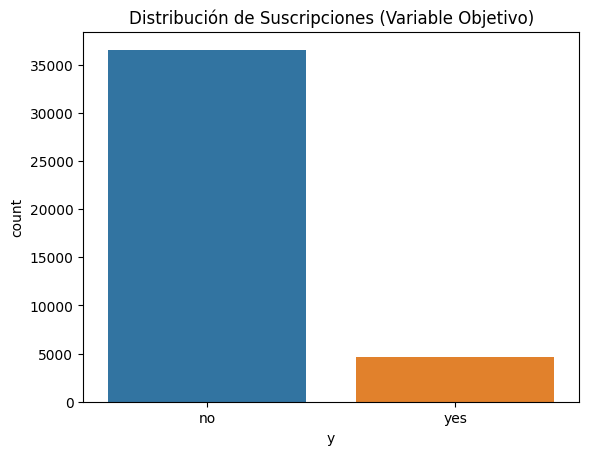

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


In [7]:
sns.countplot(x='y', data=df, hue = 'y')
plt.title('Distribución de Suscripciones (Variable Objetivo)')
plt.show()

print(df['y'].value_counts(normalize=True) * 100)

La variable objetivo está desvalanceada

# - Análisis de Variables Numéricas (Perfil del cliente y Economía)

In [8]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


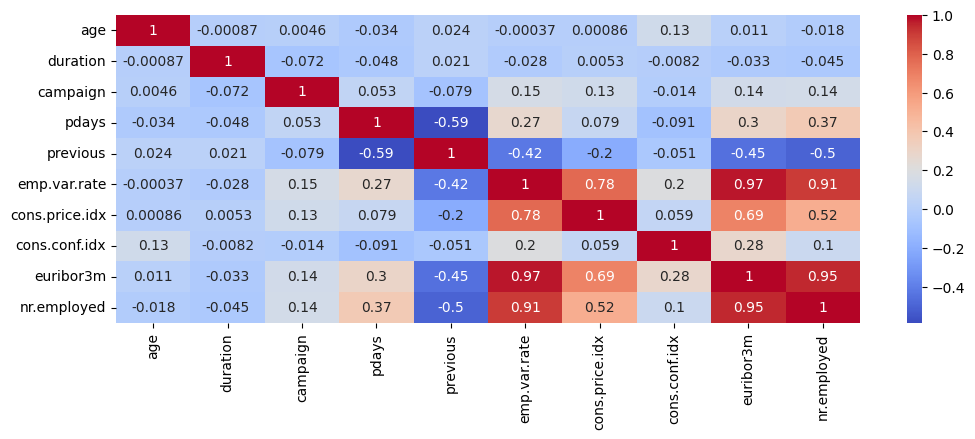

In [9]:
corr_matrix = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", ax=ax)
plt.show()

En los indicadores económicos hay una relación casi perfecta entre euribor3m, nr.employed y emp.var.rate. por lo que aportarían la misma información al modelo. 
Solo me queraía con una de ellas, por ejemplo, euribor3m y eliminan las demás para simplificar el modelo.

In [10]:
df.drop(["nr.employed", "emp.var.rate"], axis = 1, inplace = True)
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,cons.price.idx,cons.conf.idx,euribor3m,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,93.994,-36.4,4.857,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,93.994,-36.4,4.857,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,93.994,-36.4,4.857,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,93.994,-36.4,4.857,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,93.994,-36.4,4.857,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,94.767,-50.8,1.028,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,94.767,-50.8,1.028,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,94.767,-50.8,1.028,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,94.767,-50.8,1.028,yes


In [11]:
# Creamos una nueva columna: 0 si es 999 (nuevo cliente), 1 si es cualquier otro valor (ya contactado)
df['pdays_contacted'] = df['pdays'].apply(lambda x: 0 if x == 999 else 1)
df.drop("pdays", axis = 1, inplace = True)
print(df['pdays_contacted'].value_counts())

pdays_contacted
0    39673
1     1515
Name: count, dtype: int64


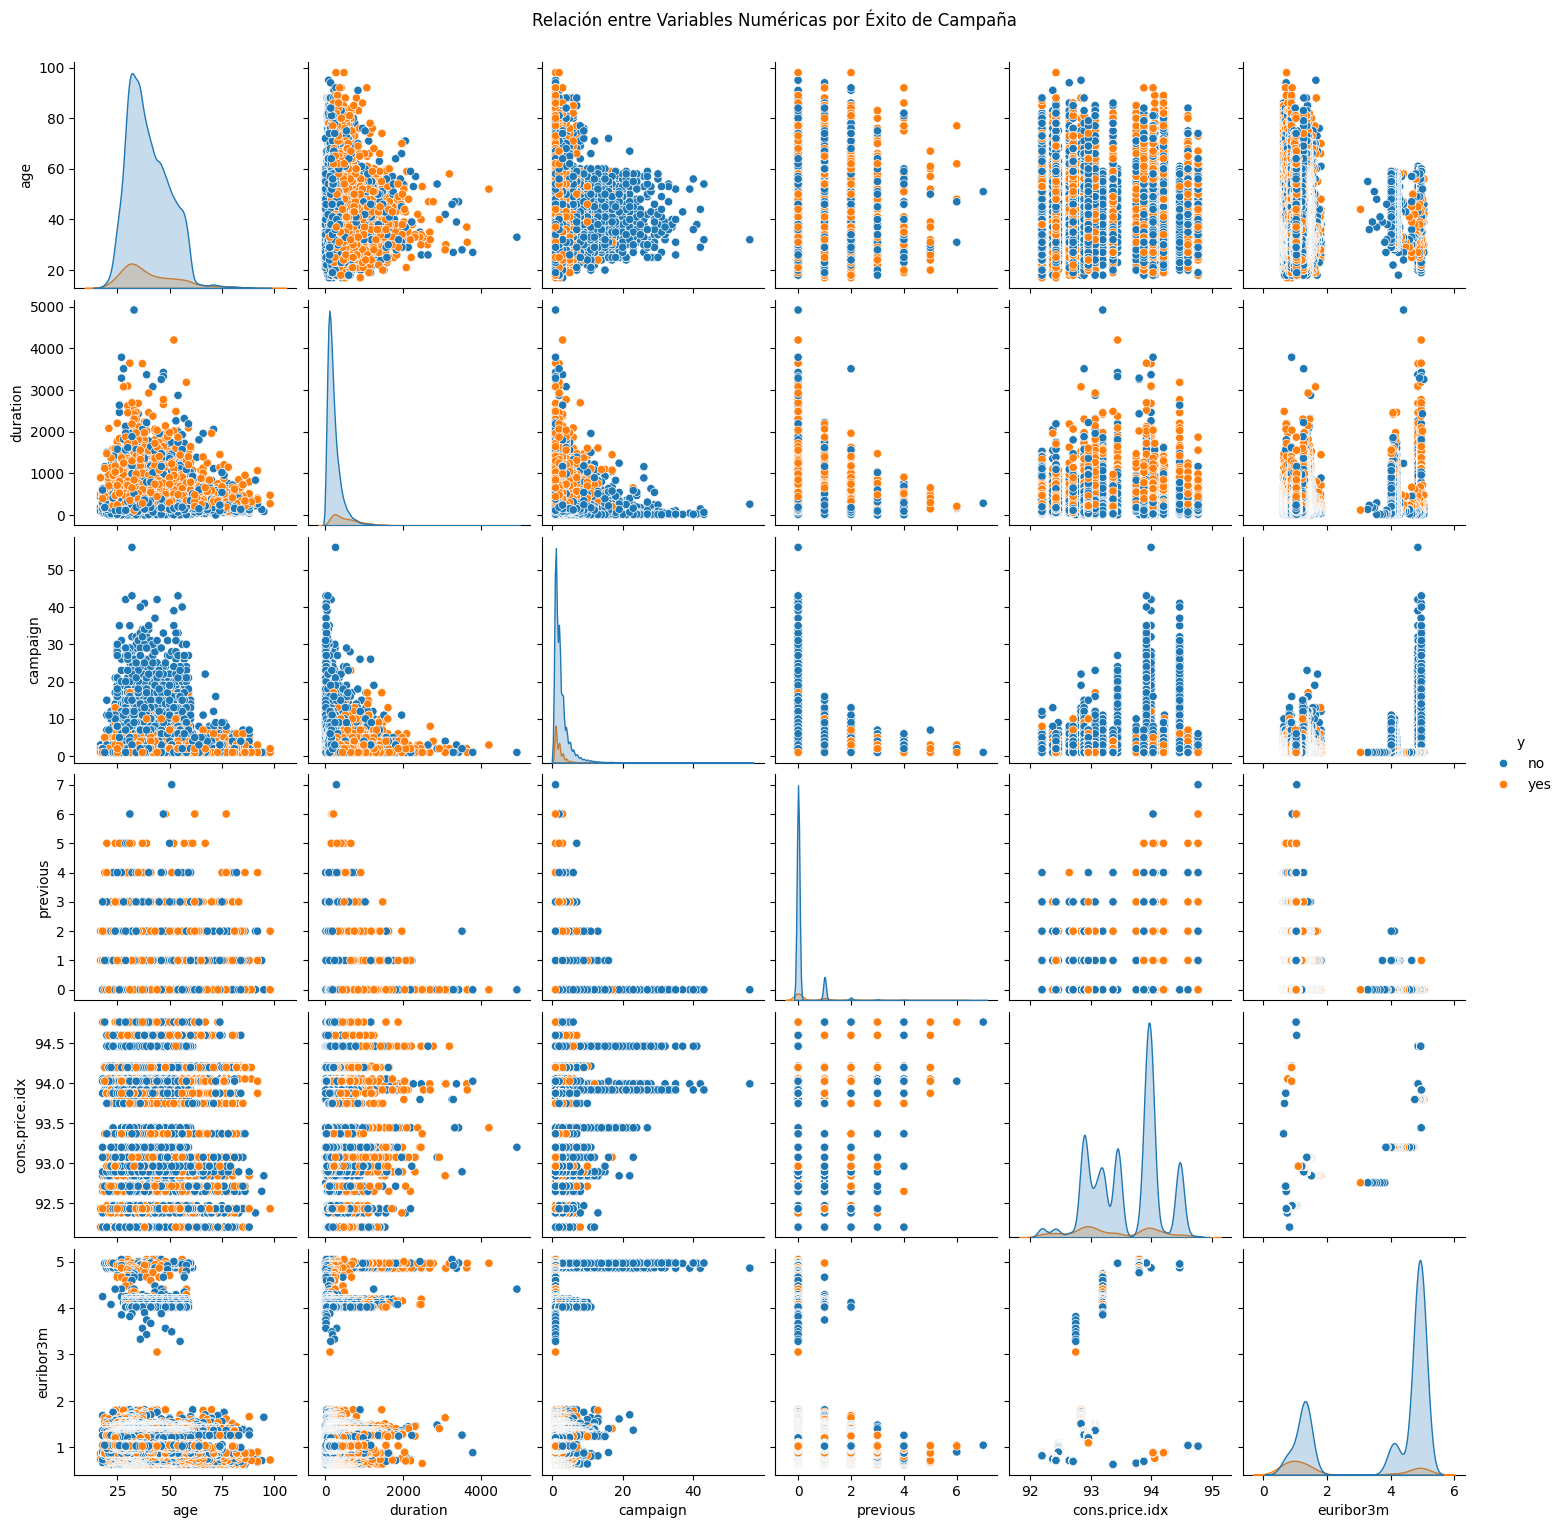

In [12]:
# 1. Seleccionamos solo las numéricas para el gráfico + la variable objetivo 'y'
vars_numericas = ['age', 'duration', 'campaign', 'previous', 'cons.price.idx', 'euribor3m', 'y']

# 2. Creamos el pairplot
# Usamos 'corner=True' para no repetir gráficos espejo y ahorrar espacio
sns.pairplot(df[vars_numericas], hue='y', diag_kind='kde')

plt.suptitle('Relación entre Variables Numéricas por Éxito de Campaña', y=1.02)
plt.show()

In [13]:
llamadas_cero = (df['duration'] == 0).sum()

print(f"Número de llamadas con duración 0: {llamadas_cero}")

# Verificamos si alguna de esas llamadas terminó en 'yes' (spoiler: no debería)
print("Suscripciones en llamadas de duración 0:")
print(df[df['duration'] == 0]['y'].value_counts())

Número de llamadas con duración 0: 4
Suscripciones en llamadas de duración 0:
y
no    4
Name: count, dtype: int64


en duration, la montaña del yes suele estar mucho más a la derecha que la del no

Nota sobre duration: Esta variable es un "trampa". Si la llamada dura 0, y siempre es "no". En la práctica, no se sabe la duración antes de llamar, por lo que muchos científicos de datos la eliminan para que el modelo sea realista.

# - Análisis de Variables Categóricas (Trabajo y Educación)

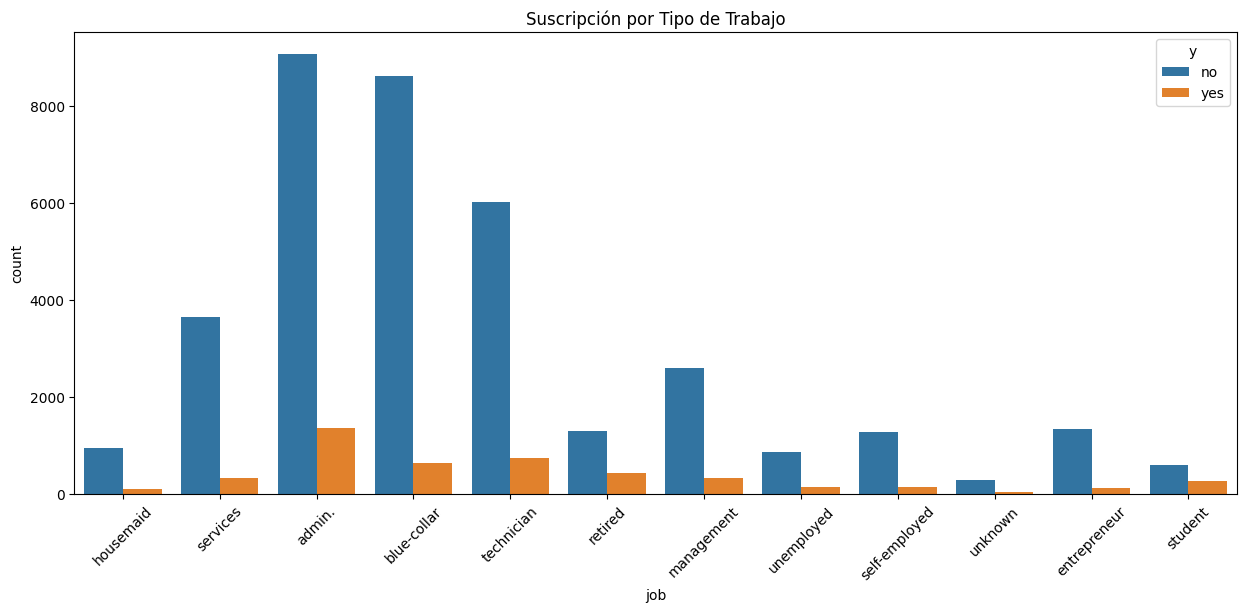

In [14]:
plt.figure(figsize=(15, 6))
sns.countplot(x='job', hue='y', data=df)
plt.xticks(rotation=45)
plt.title('Suscripción por Tipo de Trabajo')
plt.show()

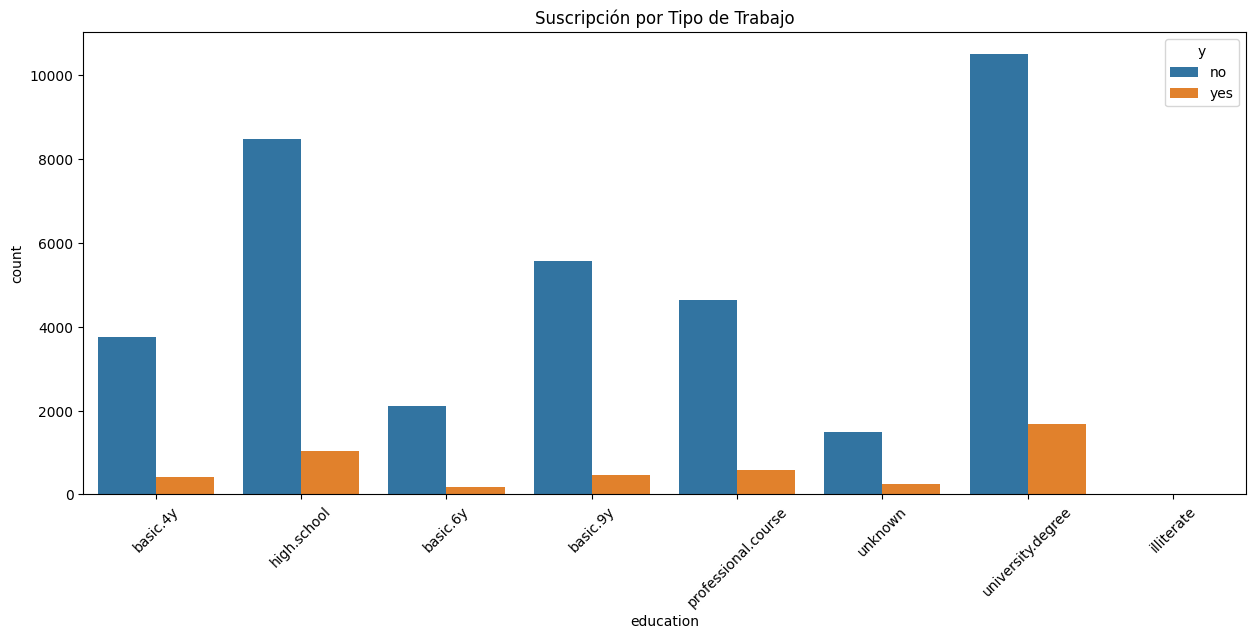

In [15]:
plt.figure(figsize=(15, 6))
sns.countplot(x='education', hue='y', data=df)
plt.xticks(rotation=45)
plt.title('Suscripción por Tipo de Trabajo')
plt.show()

In [16]:
# como el tipo de educación está muy fragmentada agrupamos los de educación básica
df['education'] = df['education'].replace(['basic.4y', 'basic.6y', 'basic.9y'], 'basic')

# 2. Eliminar duration (para un modelo predictivo real) 
# y las económicas redundantes que ya mencionamos
cols_a_eliminar = ['duration']
df.drop(columns=cols_a_eliminar, inplace=True)

# 3. Ver cómo quedó el nuevo listado de educación
print("Nuevos valores únicos en EDUCATION:")
print(df['education'].unique())

Nuevos valores únicos en EDUCATION:
<StringArray>
[              'basic',         'high.school', 'professional.course',
             'unknown',   'university.degree',          'illiterate']
Length: 6, dtype: str


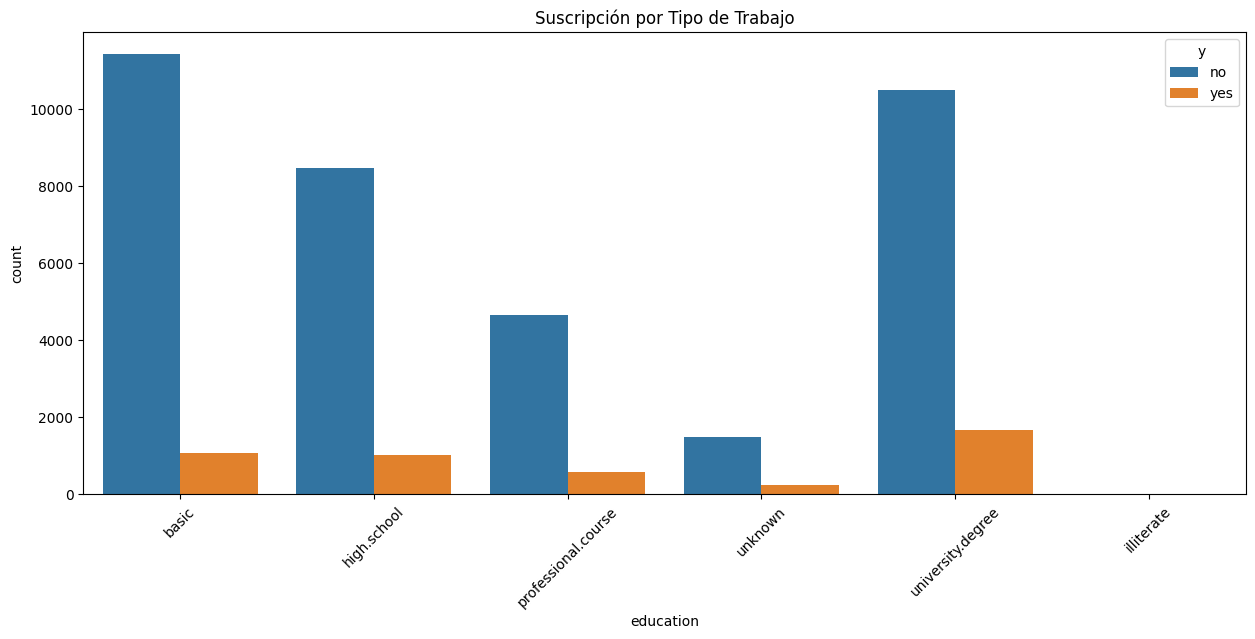

In [17]:
plt.figure(figsize=(15, 6))
sns.countplot(x='education', hue='y', data=df)
plt.xticks(rotation=45)
plt.title('Suscripción por Tipo de Trabajo')
plt.show()

Desbalanceo: Si el 90% dice "no", el modelo tenderá a predecir siempre "no".

Outliers: Revisa si hay edades imposibles o campañas con demasiadas llamadas al mismo cliente.

Relación Económica: Mira si cuando el euribor3m o emp.var.rate están bajos, la gente contrata más depósitos (suele pasar).

In [18]:
# Conversión de variables categóricas en numéricas
orden_educacion = {
    'illiterate': 0,
    'basic': 1,
    'high.school': 2,
    'professional.course': 3,
    'university.degree': 4,
    'unknown': 5
}

df['education'] = df['education'].map(orden_educacion)

columnas_restantes = ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

# Creamos las variables dummies
df = pd.get_dummies(df, columns=columnas_restantes, drop_first=True)

# Conversión de la variable objetivo 'y' en binaria (0 y 1)
df['y'] = df['y'].map({'no': 0, 'yes': 1})

print("Forma final del DataFrame:", df.shape)
df.head()

Forma final del DataFrame: (41188, 45)


,age,education,campaign,previous,cons.price.idx,cons.conf.idx,euribor3m,y,pdays_contacted,job_blue-collar,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,1,1,0,93.994,-36.4,4.857,0,0,False,...,True,False,False,False,True,False,False,False,True,False
1,57,2,1,0,93.994,-36.4,4.857,0,0,False,...,True,False,False,False,True,False,False,False,True,False
2,37,2,1,0,93.994,-36.4,4.857,0,0,False,...,True,False,False,False,True,False,False,False,True,False
3,40,1,1,0,93.994,-36.4,4.857,0,0,False,...,True,False,False,False,True,False,False,False,True,False
4,56,2,1,0,93.994,-36.4,4.857,0,0,False,...,True,False,False,False,True,False,False,False,True,False


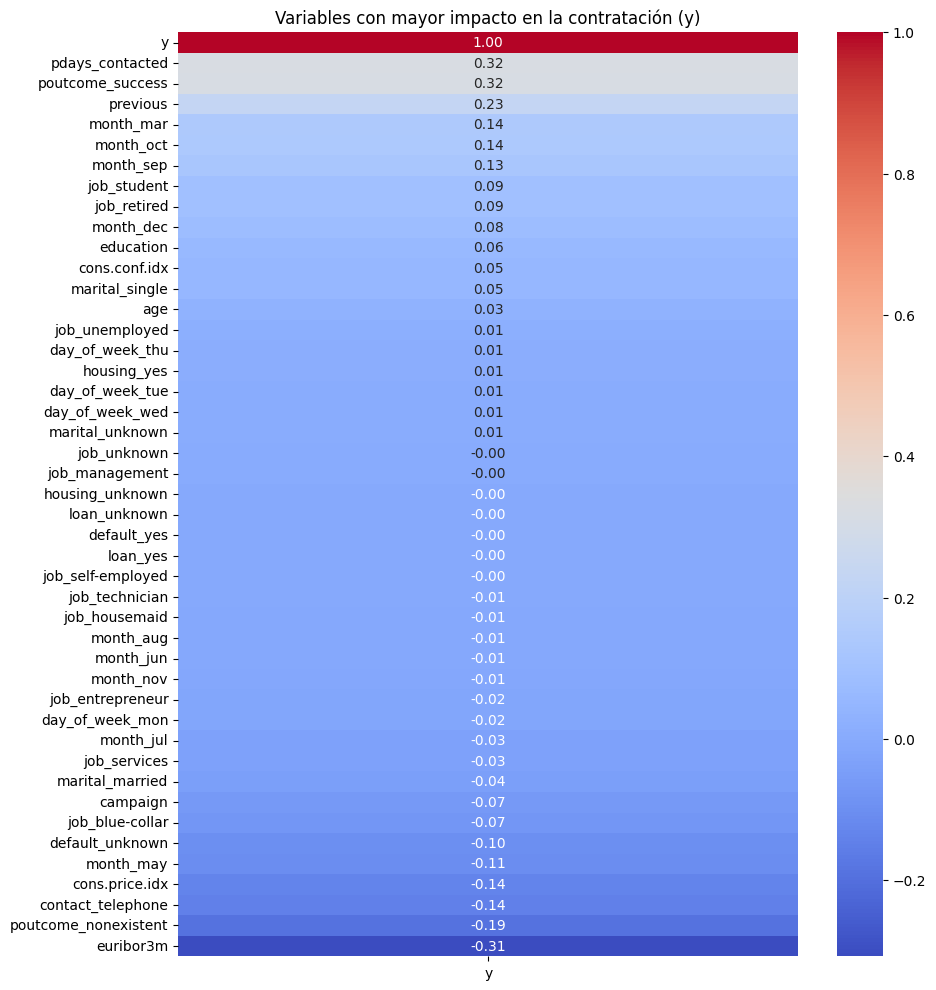

In [19]:
corr_matrix = df.corr()

# 2. Filtramos para ver solo la relación con la variable objetivo 'y'
# Ordenamos de mayor a menor para ver qué influye más
y_corr = corr_matrix['y'].sort_values(ascending=False)

# 3. Graficamos las 15 variables que más influyen (positiva o negativamente)
plt.figure(figsize=(10, 12))
sns.heatmap(y_corr.to_frame(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Variables con mayor impacto en la contratación (y)')
plt.show()

euribor3m tiene correlación negativa fuerte (si los intereses suben, la gente contrata menos depósitos a largo plazo).


poutcome_success muestra que si el cliente ya dijo que "sí" en la campaña anterior, es muy probable que vuelva a decir que "sí".


Por la correlación con pdays_contacted se puede decir que el banco tiene más éxito con clientes antiguos.


Los meses que mejor resultados han dado son marzo, octubre y septiembre. En menor proporción diciembre.


Los empleos que mejor correlacionan son estudiantes y jubilados. Los trabajadores "blue-collar" (obreros) muestran una correlación negativa.

Tienden ha haber mejores resultados con clientes solteros que con casados.


# - Modelo de regresión logística 

In [20]:
#Primero escalo las variables
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

# Creamos un Pipeline: Primero escala, luego entrena
# Usamos el solver 'saga', que es más robusto para datasets grandes
model_final = make_pipeline(
    StandardScaler(), 
    LogisticRegression(
        max_iter=5000, 
        class_weight={0: 1, 1: 5}, 
        solver='saga', 
        random_state=42
    )
)


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model_base = LogisticRegression(max_iter=1000) # Aumentamos iteraciones para que converja
model_base.fit(X_train, y_train)

y_pred_base = model_base.predict(X_test)
print("--- MODELO BASE ---")
print(classification_report(y_test, y_pred_base))

--- MODELO BASE ---
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7310
           1       0.69      0.20      0.32       928

    accuracy                           0.90      8238
   macro avg       0.80      0.60      0.63      8238
weighted avg       0.88      0.90      0.87      8238



El modelo da una buena predicción, pero al estar desbalanceado, la predicción del "sí" es sensiblemente más baja.

En la optimización, se añade class_weight='balanced' para que el modelo le dé más importancia a los "síes".

In [22]:
model_opt = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model_opt.fit(X_train, y_train)

# Evaluación optimizada
y_pred_opt = model_opt.predict(X_test)
print("\n--- MODELO OPTIMIZADO (Balanced) ---")
print(classification_report(y_test, y_pred_opt))


--- MODELO OPTIMIZADO (Balanced) ---
              precision    recall  f1-score   support

           0       0.95      0.84      0.89      7310
           1       0.34      0.66      0.45       928

    accuracy                           0.82      8238
   macro avg       0.65      0.75      0.67      8238
weighted avg       0.88      0.82      0.84      8238



/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


El Modelo Base tiene un accuracy del 90%, pero casi siempre predice el "no" (clase 0) por el desbalanceo. Solo detecta al 20% de los clientes interesados (Recall de 1 = 0.20). El banco perdería al 80% de sus ventas potenciales.


El Modelo Optimizado (Balanced) baja el accuracy al 82%, pero ahora detecta al 65% de los clientes interesados. Triplicando la capacidad de captación. Sin embargo, ahora molestas a más gente que dirá que no (baja la Precisión de 1 a 0.34).